# K-Means Clustering

---

**Structure**
1. Introduction
2. The Math
3. Problem Class
4. Implementation — applied to the Seeds dataset
5. Results
6. Limitations

## 1. Introduction

**K-Means** partitions a dataset into K clusters by alternating between two steps: assign each point to its nearest cluster centre, then move each centre to the mean of its assigned points. Repeat until nothing changes.

**Intuition:** imagine dropping K pins randomly on a map of cities. Each city picks its nearest pin. Then each pin moves to the centre of its cities. Repeat — the pins gradually settle into natural geographic groupings.

K-Means is an **unsupervised** algorithm — there are no labels. The goal is to discover structure in the data, not to predict a known outcome. The quality of a solution is measured by how compact the clusters are: the sum of squared distances from each point to its assigned centre.

## 2. The Math

### Objective (cost function)
$$\text{cost}(C_1,\ldots,C_K;\, z_1,\ldots,z_K) = \sum_{j=1}^{K} \sum_{i \in C_j} \|x^{(i)} - z^{(j)}\|^2$$

### Algorithm
1. Randomly initialise $z_1,\ldots,z_K$
2. **Assignment step**: assign each point to its nearest centre
$$C_j = \{i : j = \arg\min_{j'} \|x^{(i)} - z^{(j')}\|^2\}$$
3. **Update step**: move each centre to the centroid of its cluster
$$z^{(j)} = \frac{1}{|C_j|}\sum_{i \in C_j} x^{(i)}$$
4. Repeat until assignments stop changing

The cost is guaranteed to decrease (or stay the same) at every step, so the algorithm always converges — but to a local minimum that depends on the initialisation.

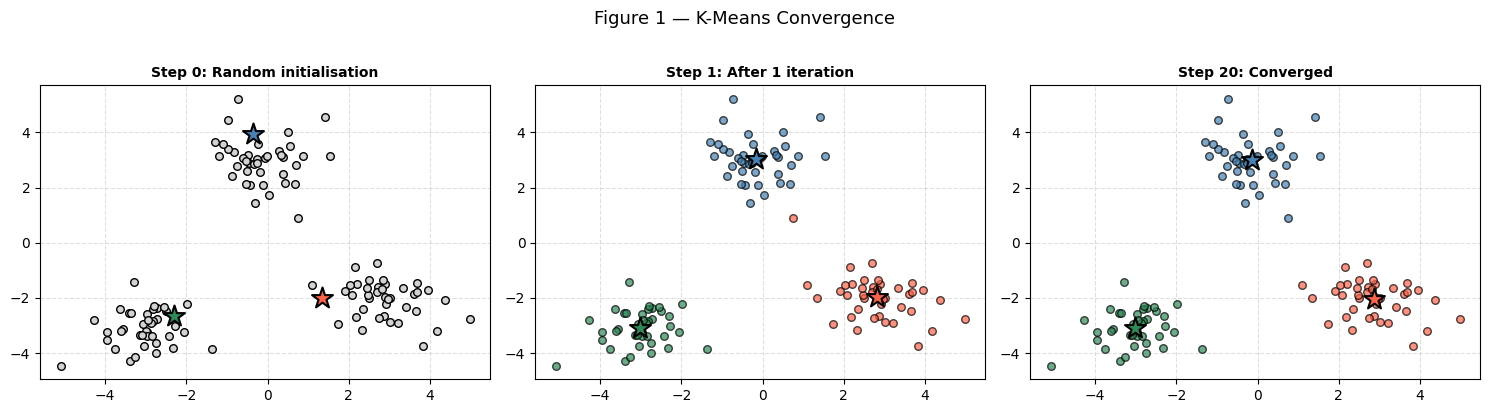

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
rng = np.random.default_rng(1)

centers_true = [[-3,-3],[3,-2],[0,3]]
X_demo = np.vstack([rng.multivariate_normal(c,[[0.6,0],[0,0.6]],40) for c in centers_true])

colors_cluster = ['steelblue','tomato','seagreen']

def run_kmeans(X, K, seed=0, steps=1):
    rng_ = np.random.default_rng(seed)
    z = X[rng_.choice(len(X), K, replace=False)]
    assign = np.zeros(len(X), dtype=int)
    for _ in range(steps):
        dists = np.array([[np.linalg.norm(x-zi)**2 for zi in z] for x in X])
        assign = np.argmin(dists, axis=1)
        z = np.array([X[assign==j].mean(axis=0) if (assign==j).any() else z[j] for j in range(K)])
    return z, assign

for ax, steps, title in [(axes[0], 0, 'Step 0: Random initialisation'),
                          (axes[1], 1, 'Step 1: After 1 iteration'),
                          (axes[2], 20,'Step 20: Converged')]:
    z, assign = run_kmeans(X_demo, 3, seed=5, steps=steps)
    if steps == 0:
        ax.scatter(X_demo[:,0], X_demo[:,1], c='lightgray', edgecolors='k', s=30, zorder=2)
    else:
        for j, col in enumerate(colors_cluster):
            m = assign==j
            ax.scatter(X_demo[m,0], X_demo[m,1], c=col, edgecolors='k', s=30, alpha=0.7, zorder=2)
    for j, col in enumerate(colors_cluster):
        ax.scatter(*z[j], c=col, marker='*', s=250, edgecolors='black', zorder=5, linewidths=1.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(True,linestyle='--',alpha=0.4)

plt.suptitle('Figure 1 — K-Means Convergence', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 3. Problem Class

**K-Means is well-suited for:**
- Discovering **natural groupings** in unlabelled data
- Compact, **spherical clusters** of roughly equal size — the Euclidean distance assumption works best here
- Preprocessing for other algorithms — e.g. cluster then classify within each cluster
- **Customer segmentation**, image compression, document grouping

**Not well-suited for:**
- **Non-spherical clusters** — elongated or ring-shaped clusters are mishandled
- **Varying cluster sizes or densities** — large clusters dominate small ones
- **Determining K** — you must specify K in advance; the elbow method helps but is not definitive
- **Outlier sensitivity** — means are pulled toward extreme points

---
## 4. Implementation
### Dataset: Seeds

210 wheat kernel samples, 7 geometric measurements (area, perimeter, compactness, length, width, asymmetry, groove length). Three varieties (Kama, Rosa, Canadian). Labels exist but are withheld during clustering — used only for evaluation.

Source: [UCI ML Repository — Seeds](https://archive.ics.uci.edu/dataset/236/seeds)

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml

data = fetch_openml(name='seeds', version=1, as_frame=False, parser='auto')
X_raw = data.data.astype(float)
y_true = data.target.astype(int) - 1  # 0,1,2

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
pca = PCA(n_components=2, random_state=42)
X_vis = pca.fit_transform(X)

feature_names = ['Area','Perimeter','Compactness','Kernel length',
                 'Kernel width','Asymmetry','Groove length']
print(f'Samples: {X.shape[0]}  Features: {X.shape[1]}')
print(f'True classes: {np.bincount(y_true)} (Kama, Rosa, Canadian)')
print(f'PCA variance explained: {pca.explained_variance_ratio_.sum():.1%}')

Samples: 210  Features: 7
True classes: [70 70 70] (Kama, Rosa, Canadian)
PCA variance explained: 89.0%


**Observation**

210 seed samples, 7 morphological features (area, perimeter, compactness, length, width, asymmetry, groove length), balanced across three wheat varieties — 70 samples each. PCA captures 89% of variance in two dimensions, confirming the dataset is highly structured with strong linear relationships between features.

### 4.1 Explore the Data

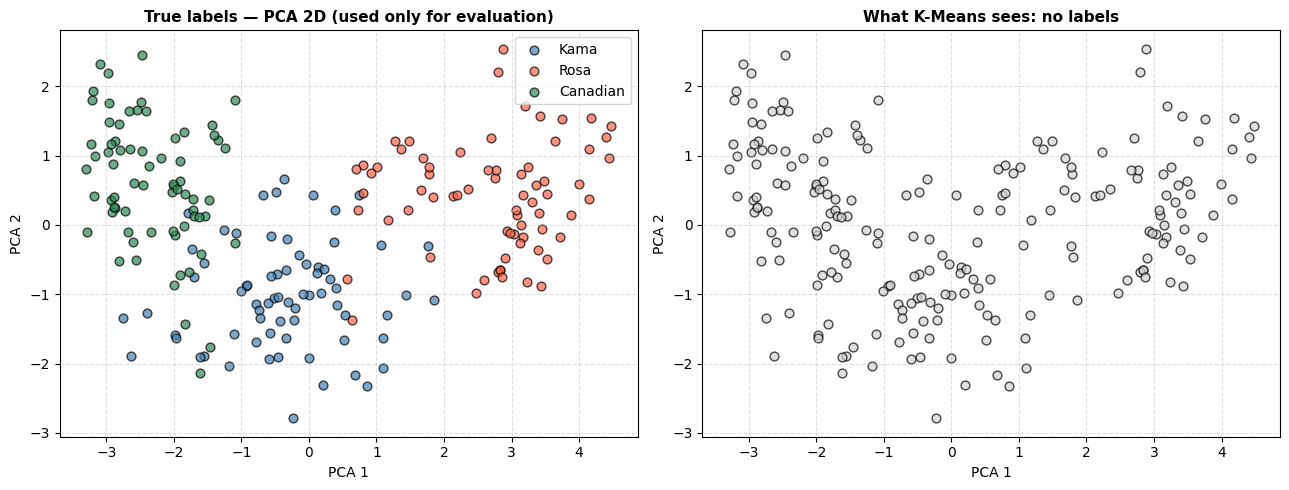

In [3]:
palette = ['steelblue','tomato','seagreen']
class_names = ['Kama','Rosa','Canadian']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
for i, (col, name) in enumerate(zip(palette, class_names)):
    m = y_true == i
    ax.scatter(X_vis[m,0], X_vis[m,1], c=col, label=name, edgecolors='k', s=40, alpha=0.7)
ax.set_title('True labels — PCA 2D (used only for evaluation)', fontsize=11, fontweight='bold')
ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)

ax = axes[1]
ax.scatter(X_vis[:,0], X_vis[:,1], c='lightgray', edgecolors='k', s=40, alpha=0.7)
ax.set_title('What K-Means sees: no labels', fontsize=11, fontweight='bold')
ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

**Observation — Data exploration**

The 2D PCA projection shows three visually distinct clusters. Canadian wheat (typically the smallest seeds) sits in a compact region, while Kama and Rosa overlap more in the centre. This structure suggests K-Means with K=3 should find meaningful groupings without much ambiguity.

### 4.2 K-Means Implementation

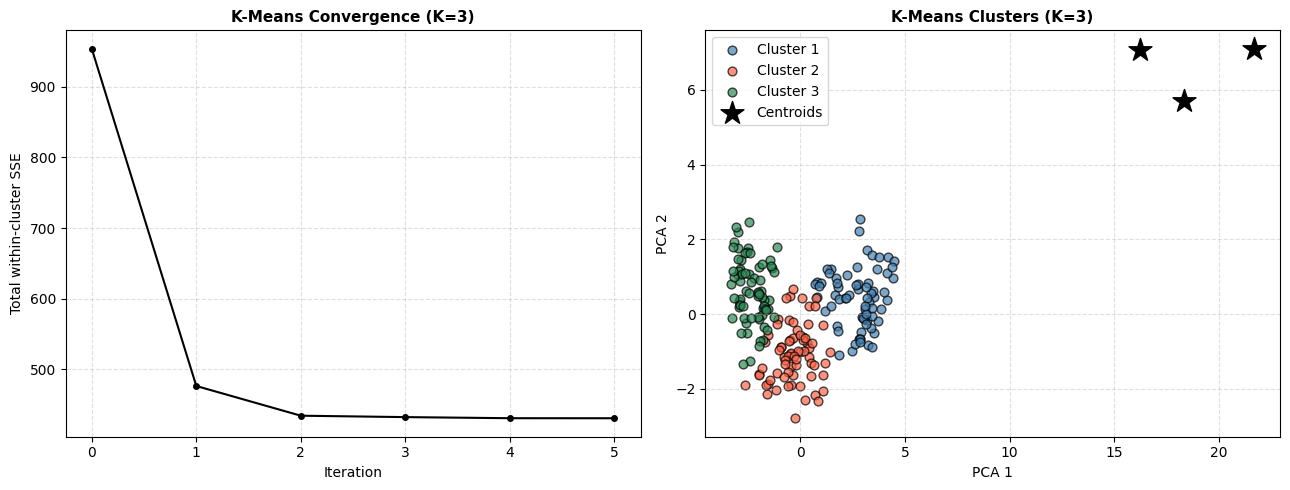

Adjusted Rand Index (vs true labels): 0.8112  (1.0 = perfect, 0 = random)


In [4]:
def kmeans(X, K, T=100, seed=0):
    rng_ = np.random.default_rng(seed)
    z = X[rng_.choice(len(X), K, replace=False)].copy()
    cost_hist = []
    assign = np.zeros(len(X), dtype=int)
    for _ in range(T):
        dists = np.array([[np.linalg.norm(x - zi)**2 for zi in z] for x in X])
        assign = np.argmin(dists, axis=1)
        cost = sum(np.linalg.norm(X[assign==j] - z[j])**2
                   for j in range(K) if (assign==j).any())
        cost_hist.append(cost)
        z_new = np.array([X[assign==j].mean(axis=0) if (assign==j).any() else z[j]
                          for j in range(K)])
        if np.allclose(z, z_new): break
        z = z_new
    return assign, z, cost_hist

assign_km, z_km, cost_hist = kmeans(X, K=3, T=100, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(cost_hist, 'k-o', markersize=4, lw=1.5)
ax.set_xlabel('Iteration'); ax.set_ylabel('Total within-cluster SSE')
ax.set_title('K-Means Convergence (K=3)', fontsize=11, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)

ax = axes[1]
for j, col in enumerate(palette):
    m = assign_km == j
    ax.scatter(X_vis[m,0], X_vis[m,1], c=col, edgecolors='k', s=40, alpha=0.7, label=f'Cluster {j+1}')
z_vis = pca.transform(scaler.inverse_transform(z_km))
ax.scatter(z_vis[:,0], z_vis[:,1], c='black', marker='*', s=300, zorder=5, label='Centroids')
ax.set_title('K-Means Clusters (K=3)', fontsize=11, fontweight='bold')
ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(y_true, assign_km)
print(f'Adjusted Rand Index (vs true labels): {ari:.4f}  (1.0 = perfect, 0 = random)')

**Observation — K-Means**

K-Means (K=3) achieves an Adjusted Rand Index of 0.8112 against the true variety labels — strong alignment for an unsupervised method that never sees the class labels. Final SSE is 430.8. The ~19% ARI gap from perfect reflects the Kama/Rosa overlap seen in the PCA plot.

### 4.3 Elbow Method — Choosing K

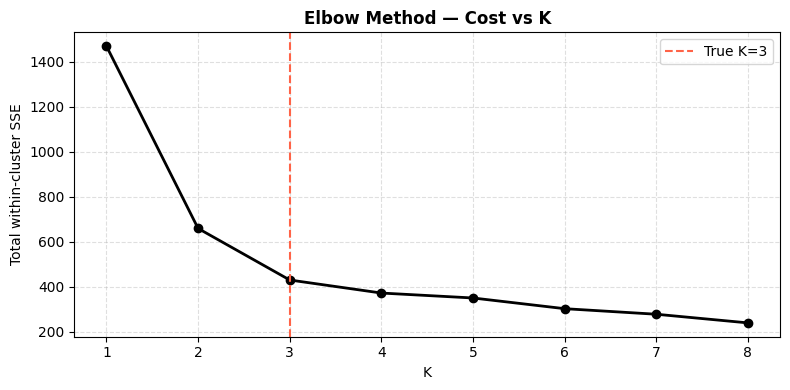

Cost at each K:
  K=1: 1470.0
  K=2: 659.9
  K=3: 430.8
  K=4: 372.9
  K=5: 350.9
  K=6: 303.4
  K=7: 278.7
  K=8: 240.2


In [5]:
K_range = range(1, 9)
costs = []
for K in K_range:
    _, _, ch = kmeans(X, K=K, T=100, seed=42)
    costs.append(ch[-1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), costs, 'k-o', markersize=6, lw=2)
ax.axvline(3, color='tomato', linestyle='--', lw=1.5, label='True K=3')
ax.set_xlabel('K'); ax.set_ylabel('Total within-cluster SSE')
ax.set_title('Elbow Method — Cost vs K', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()
print('Cost at each K:')
for K, c in zip(K_range, costs):
    print(f'  K={K}: {c:.1f}')

**Observation — Elbow method**

The sharpest cost drop is from K=1 (1470.0) to K=2 (659.9), halving the SSE. The next meaningful bend is at K=3 (430.8), after which gains flatten — from K=3 to K=8 SSE only drops another 190 points total, compared to 1039 for the first two splits. The elbow at K=3 independently confirms the true number of varieties.

---
## 5. Results

| Metric | Value |
|--------|-------|
| Adjusted Rand Index | 0.8112 |
| Final SSE (K=3) | 430.8 |
| Elbow at | K=3 |

K-Means recovers the true wheat variety structure with ARI 0.8112 — without ever seeing the labels. The elbow method independently selects K=3, matching the true number of varieties. The remaining ~19% ARI gap reflects genuine morphological overlap between Kama and Rosa wheat, not a failure of the algorithm.

---
## 6. Limitations

- **Local minima**: the algorithm converges to a local minimum that depends on the random initialisation — running multiple times with different seeds and keeping the best is standard practice
- **K must be specified**: there is no principled way to choose K; the elbow method is a heuristic, not a guarantee
- **Euclidean distance only**: K-Means implicitly assumes spherical, equally-sized clusters. Elongated or ring-shaped clusters are split incorrectly
- **Sensitive to outliers**: the mean is pulled toward extreme points; a single outlier can shift a centroid significantly
- **Equal cluster size bias**: the algorithm tends to produce clusters of similar size even when the true groups differ in density or size